<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/API/NeqSimProcessAPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NeqSim Process API: self-contained engineering services

**Audience.** Process engineers, digital-twin developers, data scientists, and software engineers
who want to expose reproducible NeqSim calculations through validated request and response
objects.

**Prerequisites.** Basic Python, phase equilibrium, process flowsheets, and JSON data structures.
All pressures are absolute. SI units are used unless `bara`, `°C`, or `kg/h` is stated explicitly.

## Learning objectives

After completing this notebook, you can:

1. define a stable, unit-aware contract for a process-calculation service;
2. map JSON-like request objects to NeqSim fluids, streams, and equipment;
3. calculate a TEG gas-dehydration case with `SimpleTEGAbsorber`;
4. calculate a three-stage offshore oil-and-gas separation and recompression process;
5. return only finite, serializable engineering results;
6. reject invalid requests without running the thermodynamic solver;
7. evaluate independent scenarios without hidden process state; and
8. verify conservation, pressure ordering, specifications, and expected trends.


## Engineering context and validity limits

A process API separates the **service contract** from the **calculation engine**. The caller
provides named values and units. A validation layer checks the request. NeqSim then creates the
thermodynamic system and process objects, runs the calculation, and returns a compact result.

The examples use local Python functions so the notebook is reproducible without credentials,
network services, or proprietary plant data. The same pure calculation functions can be wrapped by
FastAPI, Quarkus, an MCP server, a batch system, or a cloud function.

These are steady-state screening models. They do not represent controller dynamics, detailed mass
transfer, vendor curves, hydrate kinetics, corrosion, relief loads, or certified equipment design.


## Governing balances and service objectives

Every steady process response must satisfy the total mass balance

$$

\dot{m}_{\mathrm{in}} = \sum_j \dot{m}_{\mathrm{out},j}

$$

where $\dot{m}$ is mass rate in kg/h and $j$ identifies external product streams.

The TEG contactor water-removal fraction is

$$

\eta_w = 1 - \frac{\dot{m}_{w,\mathrm{dry}}}{\dot{m}_{w,\mathrm{wet}}}

$$

where $\dot{m}_{w,\mathrm{wet}}$ and $\dot{m}_{w,\mathrm{dry}}$ are water rates before and after
the absorber in kg/h.

Total compressor power is the sum over compressor stages:

$$

\dot{W}_{\mathrm{total}} = \sum_k \dot{W}_k

$$

where $\dot{W}_k$ is shaft power in kW for stage $k$.

An API calculation is useful only when the response is deterministic for the same request, finite,
unit-labelled, and accompanied by validity checks.


## Clean Google Colab setup

The setup installs the current public PyPI package only when NeqSim is absent. It does not use a
local checkout, an editable install, an unpublished JAR, or a hidden data file.


In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )


## Imports and runtime evidence

The Python package starts NeqSim's released Java library through JPype. Runtime versions are
reported because a production service should include calculation provenance in logs or metadata.


In [2]:
import json
import os
import platform
import subprocess
from importlib.metadata import version

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-process-api")

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
import pandas as pd

from neqsim import jneqsim
from neqsim.thermo import fluid, hydt, watersaturate


NEQSIM_VERSION = version("neqsim")
PYTHON_VERSION = platform.python_version()
JAVA_VERSION = subprocess.check_output(
    ["java", "-version"],
    stderr=subprocess.STDOUT,
    text=True,
).splitlines()[0]

SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
Stream = jneqsim.process.equipment.stream.Stream
Heater = jneqsim.process.equipment.heatexchanger.Heater
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Mixer = jneqsim.process.equipment.mixer.Mixer
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
SimpleTEGAbsorber = jneqsim.process.equipment.absorber.SimpleTEGAbsorber

print(f"NeqSim: {NEQSIM_VERSION}")
print(f"Python: {PYTHON_VERSION}")
print(f"Java: {JAVA_VERSION}")


NeqSim: 3.16.0
Python: 3.12.13
Java: openjdk version "17.0.19" 2026-04-21


## Request schemas, units, and validation

Each endpoint has explicit defaults and allowable ranges. Required pressure ordering is part of the
offshore-process contract because reversing stages would create a physically different flowsheet.
Fractions are dimensionless and must remain between zero and one.


In [3]:
TEG_DEFAULTS = {
    "feed_gas_rate_kg_per_h": 100_000.0,
    "feed_temperature_C": 35.0,
    "feed_pressure_bara": 70.0,
    "lean_teg_rate_kg_per_h": 5_500.0,
    "lean_teg_mass_fraction": 0.99,
    "contactor_stages": 4,
    "stage_efficiency": 0.70,
    "contactor_diameter_m": 1.6,
}

OFFSHORE_DEFAULTS = {
    "feed_rate_kg_per_h": 100_000.0,
    "feed_temperature_C": 65.0,
    "feed_pressure_bara": 95.0,
    "first_stage_pressure_bara": 70.0,
    "second_stage_pressure_bara": 15.0,
    "third_stage_pressure_bara": 2.0,
    "oil_heater_temperature_C": 65.0,
    "compressor_suction_temperature_C": 25.0,
    "export_pressure_bara": 140.0,
    "compressor_efficiency": 0.75,
}


def validate_request(payload, defaults, endpoint):
    unknown_keys = sorted(set(payload) - set(defaults))
    if unknown_keys:
        raise ValueError(f"Unknown fields: {unknown_keys}")

    request = dict(defaults)
    request.update(payload)

    for name, value in request.items():
        if not isinstance(value, (int, float)):
            raise ValueError(f"{name} must be numeric")
        if not np.isfinite(float(value)):
            raise ValueError(f"{name} must be finite")

    if endpoint == "teg":
        if request["feed_gas_rate_kg_per_h"] <= 0.0:
            raise ValueError("feed_gas_rate_kg_per_h must be positive")
        if request["lean_teg_rate_kg_per_h"] <= 0.0:
            raise ValueError("lean_teg_rate_kg_per_h must be positive")
        if not 0.95 <= request["lean_teg_mass_fraction"] < 1.0:
            raise ValueError("lean_teg_mass_fraction must be in [0.95, 1.0)")
        if not 0.0 < request["stage_efficiency"] <= 1.0:
            raise ValueError("stage_efficiency must be in (0, 1]")

    if endpoint == "offshore":
        pressures = [
            request["feed_pressure_bara"],
            request["first_stage_pressure_bara"],
            request["second_stage_pressure_bara"],
            request["third_stage_pressure_bara"],
        ]
        if not all(
            pressures[index] > pressures[index + 1]
            for index in range(len(pressures) - 1)
        ):
            raise ValueError("separator pressures must decrease stage by stage")
        if request["export_pressure_bara"] <= request["first_stage_pressure_bara"]:
            raise ValueError("export pressure must exceed first-stage pressure")
        if not 0.5 <= request["compressor_efficiency"] <= 0.9:
            raise ValueError("compressor_efficiency must be in [0.5, 0.9]")

    return request


print("TEG fields:", sorted(TEG_DEFAULTS))
print("Offshore fields:", sorted(OFFSHORE_DEFAULTS))


TEG fields: ['contactor_diameter_m', 'contactor_stages', 'feed_gas_rate_kg_per_h', 'feed_pressure_bara', 'feed_temperature_C', 'lean_teg_mass_fraction', 'lean_teg_rate_kg_per_h', 'stage_efficiency']
Offshore fields: ['compressor_efficiency', 'compressor_suction_temperature_C', 'export_pressure_bara', 'feed_pressure_bara', 'feed_rate_kg_per_h', 'feed_temperature_C', 'first_stage_pressure_bara', 'oil_heater_temperature_C', 'second_stage_pressure_bara', 'third_stage_pressure_bara']


## Service and solver workflow

The blue path represents the caller-facing contract. The green path represents NeqSim's physical
calculation. A service should not expose mutable Java objects in its response; only serializable
values, units, status, and validation evidence cross the boundary.


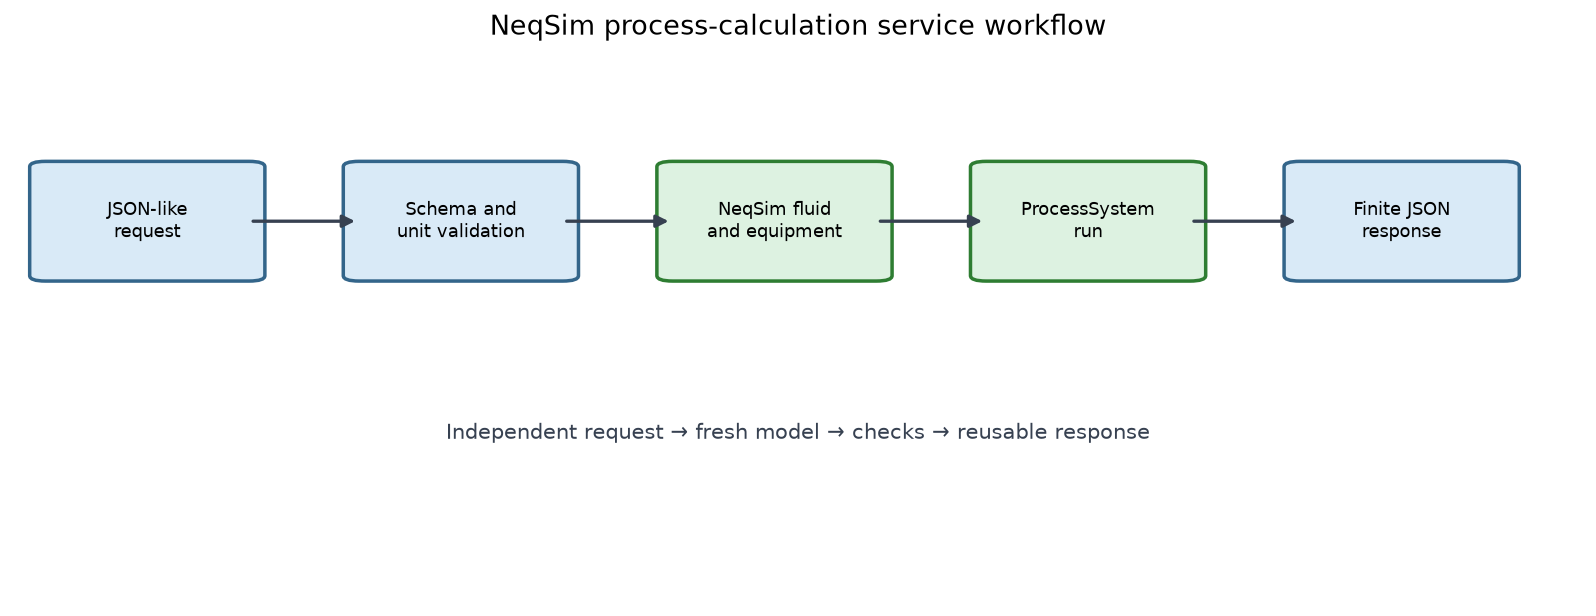

In [4]:
fig, axis = plt.subplots(figsize=(11.5, 4.5))
axis.set_xlim(0.0, 1.0)
axis.set_ylim(0.0, 1.0)
axis.axis("off")

boxes = [
    (0.02, 0.60, "JSON-like\nrequest", "#D9EAF7", "#33658A"),
    (0.22, 0.60, "Schema and\nunit validation", "#D9EAF7", "#33658A"),
    (0.42, 0.60, "NeqSim fluid\nand equipment", "#DDF2E1", "#2E7D32"),
    (0.62, 0.60, "ProcessSystem\nrun", "#DDF2E1", "#2E7D32"),
    (0.82, 0.60, "Finite JSON\nresponse", "#D9EAF7", "#33658A"),
]

for x_position, y_position, label, face_color, edge_color in boxes:
    patch = FancyBboxPatch(
        (x_position, y_position),
        0.13,
        0.20,
        boxstyle="round,pad=0.01",
        facecolor=face_color,
        edgecolor=edge_color,
        linewidth=1.8,
    )
    axis.add_patch(patch)
    axis.text(
        x_position + 0.065,
        y_position + 0.10,
        label,
        ha="center",
        va="center",
        fontsize=9.5,
    )

for start_x, end_x in [
    (0.15, 0.22),
    (0.35, 0.42),
    (0.55, 0.62),
    (0.75, 0.82),
]:
    axis.add_patch(
        FancyArrowPatch(
            (start_x, 0.70),
            (end_x, 0.70),
            arrowstyle="-|>",
            mutation_scale=13,
            linewidth=1.7,
            color="#374151",
        )
    )

axis.text(
    0.50,
    0.30,
    "Independent request → fresh model → checks → reusable response",
    ha="center",
    fontsize=11,
    color="#374151",
)
axis.set_title("NeqSim process-calculation service workflow", fontsize=14, pad=12)
plt.tight_layout()
plt.show()


The calculation functions below receive complete request dictionaries and construct fresh
`ProcessSystem` objects. This prevents one request from inheriting a setpoint, recycle state, or
thermodynamic object from an earlier request.


## Shared thermodynamic helpers

The TEG case uses SRK-CPA because water and glycol association materially affects equilibrium. The
offshore hydrocarbon process uses Peng–Robinson. Component mass rates are calculated from all
phases in a stream, avoiding assumptions about which phase index contains water.


In [5]:
def component_mass_rate(stream_object, component_name):
    thermo_system = stream_object.getFluid()
    mass_rate_kg_per_h = 0.0

    for phase_index in range(int(thermo_system.getNumberOfPhases())):
        component = thermo_system.getPhase(phase_index).getComponent(component_name)
        molar_rate_mol_per_s = float(component.getNumberOfMolesInPhase())
        molar_mass_kg_per_mol = float(component.getMolarMass())
        mass_rate_kg_per_h += (
            molar_rate_mol_per_s
            * molar_mass_kg_per_mol
            * 3_600.0
        )

    return mass_rate_kg_per_h


def water_ppmv(thermo_system):
    gas_water_fraction = float(
        thermo_system.getPhase(0).getComponent("water").getx()
    )
    return 1.0e6 * gas_water_fraction


def build_wet_gas(temperature_C, pressure_bara):
    wet_system = SystemSrkCPAstatoil(temperature_C + 273.15, pressure_bara)
    composition = {
        "nitrogen": 1.0,
        "CO2": 2.0,
        "methane": 87.0,
        "ethane": 6.0,
        "propane": 3.0,
        "n-butane": 0.8,
        "water": 0.2,
        "TEG": 1.0e-12,
    }

    for component_name, amount in composition.items():
        wet_system.addComponent(component_name, amount)

    wet_system.setMixingRule(10)
    wet_system.setMultiPhaseCheck(True)
    wet_system.init(0)
    return wet_system


def saturated_water_ppmv(temperature_C, pressure_bara):
    gas_system = SystemSrkCPAstatoil(temperature_C + 273.15, pressure_bara)
    composition = {
        "nitrogen": 1.0,
        "CO2": 2.0,
        "methane": 87.0,
        "ethane": 6.0,
        "propane": 3.0,
        "n-butane": 0.8,
        "water": 1.0e-8,
        "TEG": 1.0e-12,
    }

    for component_name, amount in composition.items():
        gas_system.addComponent(component_name, amount)

    gas_system.setMixingRule(10)
    gas_system.setMultiPhaseCheck(True)
    watersaturate(gas_system)
    return water_ppmv(gas_system)


def estimate_water_dewpoint_C(target_water_ppmv, pressure_bara):
    lower_temperature_C = -70.0
    upper_temperature_C = 25.0

    for _ in range(18):
        midpoint_temperature_C = (
            lower_temperature_C + upper_temperature_C
        ) / 2.0
        midpoint_water_ppmv = saturated_water_ppmv(
            midpoint_temperature_C,
            pressure_bara,
        )
        if midpoint_water_ppmv < target_water_ppmv:
            lower_temperature_C = midpoint_temperature_C
        else:
            upper_temperature_C = midpoint_temperature_C

    return (lower_temperature_C + upper_temperature_C) / 2.0


## Endpoint 1: TEG gas-dehydration calculation

`SimpleTEGAbsorber` receives a wet-gas stream and a lean-solvent stream. Stage count, stage
efficiency, solvent purity, circulation, and contactor diameter are supplied through the request.
NeqSim calculates dry gas, rich TEG, transfer effectiveness, and gas-loading diagnostics.

The screening reboiler duty adds an assumed $3.6\ \mathrm{MJ/kg}$ of removed water to the sensible
heat required to raise circulating TEG from $90.0\ ^\circ\mathrm{C}$ to
$197.5\ ^\circ\mathrm{C}$ with $c_p = 2.5\ \mathrm{kJ/(kg\,K)}$. It is an explicit service-level
estimate, not a rigorous regenerator model.


In [6]:
def build_teg_process(request):
    wet_gas_fluid = build_wet_gas(
        request["feed_temperature_C"],
        request["feed_pressure_bara"],
    )
    wet_gas_stream = Stream("Wet feed gas", wet_gas_fluid)
    wet_gas_stream.setFlowRate(
        request["feed_gas_rate_kg_per_h"],
        "kg/hr",
    )
    wet_gas_stream.setTemperature(request["feed_temperature_C"], "C")
    wet_gas_stream.setPressure(request["feed_pressure_bara"], "bara")

    lean_teg_fluid = SystemSrkCPAstatoil(
        request["feed_temperature_C"] + 273.15,
        request["feed_pressure_bara"],
    )
    for component_name in [
        "nitrogen",
        "CO2",
        "methane",
        "ethane",
        "propane",
        "n-butane",
    ]:
        lean_teg_fluid.addComponent(component_name, 1.0e-12)

    lean_teg_fluid.addComponent(
        "water",
        100.0 * (1.0 - request["lean_teg_mass_fraction"]),
    )
    lean_teg_fluid.addComponent(
        "TEG",
        100.0 * request["lean_teg_mass_fraction"],
    )
    lean_teg_fluid.setMixingRule(10)
    lean_teg_fluid.setMultiPhaseCheck(True)

    lean_teg_stream = Stream("Lean TEG", lean_teg_fluid)
    lean_teg_stream.setFlowRate(
        request["lean_teg_rate_kg_per_h"],
        "kg/hr",
    )
    lean_teg_stream.setTemperature(request["feed_temperature_C"], "C")
    lean_teg_stream.setPressure(request["feed_pressure_bara"], "bara")

    absorber = SimpleTEGAbsorber("TEG contactor")
    absorber.addGasInStream(wet_gas_stream)
    absorber.addSolventInStream(lean_teg_stream)
    absorber.setNumberOfStages(int(request["contactor_stages"]))
    absorber.setStageEfficiency(request["stage_efficiency"])
    absorber.setInternalDiameter(request["contactor_diameter_m"])

    process = ProcessSystem()
    process.add(wet_gas_stream)
    process.add(lean_teg_stream)
    process.add(absorber)
    process.run()

    return process, wet_gas_stream, lean_teg_stream, absorber


In [7]:
def calculate_teg(request, calculate_special_properties=True):
    process, wet_gas, lean_teg, absorber = build_teg_process(request)
    dry_gas = absorber.getGasOutStream()
    rich_teg = absorber.getLiquidOutStream()

    wet_water_rate = component_mass_rate(wet_gas, "water")
    dry_water_rate = component_mass_rate(dry_gas, "water")
    inlet_mass = (
        wet_gas.getFlowRate("kg/hr")
        + lean_teg.getFlowRate("kg/hr")
    )
    outlet_mass = (
        dry_gas.getFlowRate("kg/hr")
        + rich_teg.getFlowRate("kg/hr")
    )
    dry_water_ppmv = water_ppmv(dry_gas.getFluid())

    water_dewpoint_C = np.nan
    hydrate_temperature_C = np.nan
    if calculate_special_properties:
        water_dewpoint_C = estimate_water_dewpoint_C(
            dry_water_ppmv,
            request["feed_pressure_bara"],
        )
        hydrate_fluid = wet_gas.getFluid().clone()
        hydrate_temperature_C = hydt(hydrate_fluid) - 273.15

    removed_water_kg_per_h = wet_water_rate - dry_water_rate
    water_regeneration_energy_kJ_per_kg = 3_600.0
    teg_heat_capacity_kJ_per_kg_K = 2.5
    teg_temperature_rise_K = 197.5 - 90.0
    reboiler_duty_kW = (
        removed_water_kg_per_h
        * water_regeneration_energy_kJ_per_kg
        + request["lean_teg_rate_kg_per_h"]
        * teg_heat_capacity_kJ_per_kg_K
        * teg_temperature_rise_K
    ) / 3_600.0

    return {
        "dry_gas_water_ppmv": dry_water_ppmv,
        "wet_gas_water_ppmv": water_ppmv(wet_gas.getFluid()),
        "water_removal_fraction": 1.0 - dry_water_rate / wet_water_rate,
        "water_dewpoint_C": water_dewpoint_C,
        "feed_hydrate_temperature_C": hydrate_temperature_C,
        "reboiler_duty_kW_screening": reboiler_duty_kW,
        "dry_gas_rate_kg_per_h": dry_gas.getFlowRate("kg/hr"),
        "rich_teg_rate_kg_per_h": rich_teg.getFlowRate("kg/hr"),
        "mass_residual_kg_per_h": inlet_mass - outlet_mass,
        "ntu": absorber.getNTU(),
        "fs_utilization_percent": (
            100.0 * absorber.getFsFactorUtilization()
        ),
    }


In [8]:
teg_request = validate_request(
    {},
    TEG_DEFAULTS,
    endpoint="teg",
)
teg_result = calculate_teg(teg_request)

teg_result_table = pd.DataFrame(
    {
        "quantity": list(teg_result),
        "value": list(teg_result.values()),
    }
)
print(teg_result_table.to_string(index=False))


                  quantity         value
        dry_gas_water_ppmv  8.252040e+00
        wet_gas_water_ppmv  1.016029e+03
    water_removal_fraction  9.958836e-01
          water_dewpoint_C -3.681266e+01
feed_hydrate_temperature_C  1.793375e+01
reboiler_duty_kW_screening  6.020014e+02
     dry_gas_rate_kg_per_h  9.975730e+04
    rich_teg_rate_kg_per_h  5.742702e+03
    mass_residual_kg_per_h  4.365575e-11
                       ntu  6.952664e+00
    fs_utilization_percent  6.011024e+01


The base contactor reduces gas water content from about $10^3$ ppmv to a single-digit value. The
water dew point is substantially below ambient conditions, while the feed hydrate-equilibrium
temperature remains above typical cold-start temperatures. Hydrate temperature and water dew
point answer different questions and should not be interchanged.


### TEG circulation sensitivity

Each circulation point creates a new contactor and process. Increasing circulation improves water
removal but increases the screening regeneration duty. The calculation therefore exposes both a
quality response and an energy trade-off.


In [9]:
teg_rates_kg_per_h = np.array([3_000.0, 5_500.0, 8_000.0, 12_000.0])
teg_sensitivity_rows = []

for teg_rate_kg_per_h in teg_rates_kg_per_h:
    request = dict(TEG_DEFAULTS)
    request["lean_teg_rate_kg_per_h"] = teg_rate_kg_per_h
    result = calculate_teg(
        request,
        calculate_special_properties=False,
    )
    teg_sensitivity_rows.append(
        {
            "TEG rate [kg/h]": teg_rate_kg_per_h,
            "Dry gas water [ppmv]": result["dry_gas_water_ppmv"],
            "Water removal [%]": (
                100.0 * result["water_removal_fraction"]
            ),
            "Reboiler duty [kW]": (
                result["reboiler_duty_kW_screening"]
            ),
            "Mass residual [kg/h]": result["mass_residual_kg_per_h"],
        }
    )

teg_sensitivity = pd.DataFrame(teg_sensitivity_rows)
print(teg_sensitivity.to_string(index=False))


 TEG rate [kg/h]  Dry gas water [ppmv]  Water removal [%]  Reboiler duty [kW]  Mass residual [kg/h]
          3000.0             11.600201          99.421254          415.048317          2.910383e-11
          5500.0              8.252040          99.588363          602.001448          4.365575e-11
          8000.0              7.497771          99.626046          788.705820          2.080924e-09
         12000.0              7.106620          99.645641         1087.354594          2.632441e-08


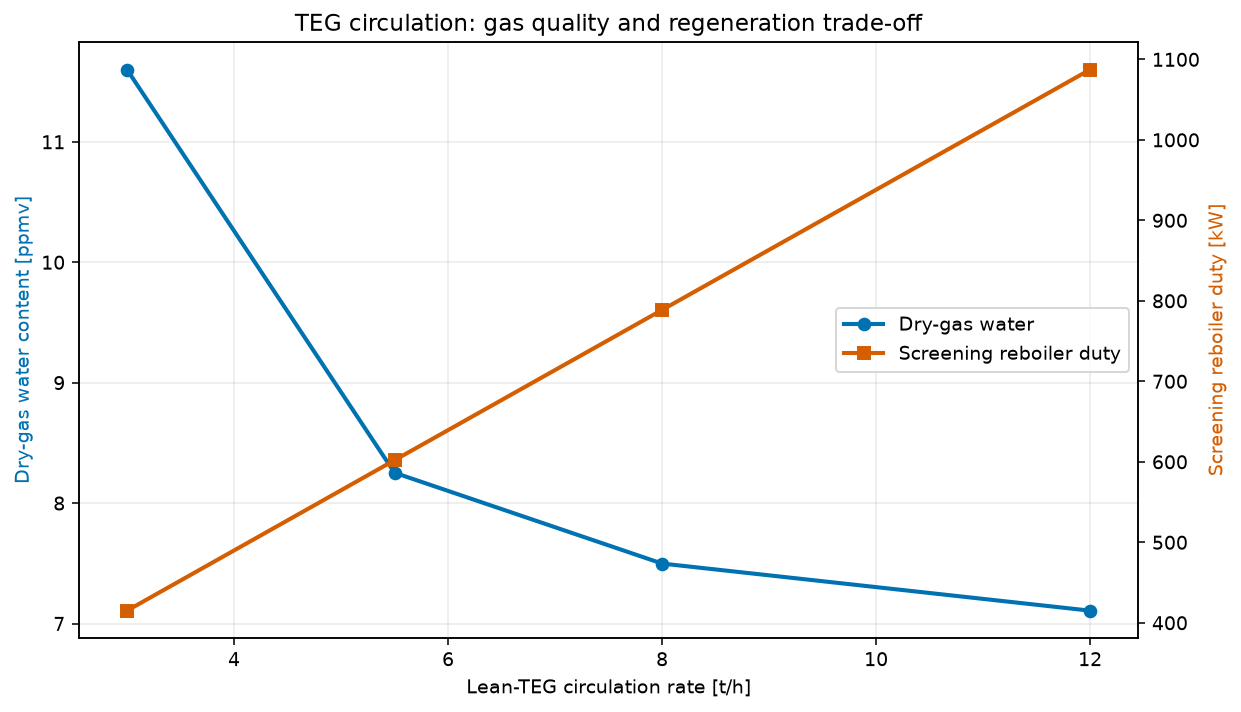

In [10]:
fig, water_axis = plt.subplots(figsize=(9.0, 5.2))
duty_axis = water_axis.twinx()

water_axis.plot(
    teg_sensitivity["TEG rate [kg/h]"] / 1_000.0,
    teg_sensitivity["Dry gas water [ppmv]"],
    color="#0072B2",
    marker="o",
    linewidth=2.1,
    label="Dry-gas water",
)
duty_axis.plot(
    teg_sensitivity["TEG rate [kg/h]"] / 1_000.0,
    teg_sensitivity["Reboiler duty [kW]"],
    color="#D55E00",
    marker="s",
    linewidth=2.1,
    label="Screening reboiler duty",
)
water_axis.set_xlabel("Lean-TEG circulation rate [t/h]")
water_axis.set_ylabel("Dry-gas water content [ppmv]", color="#0072B2")
duty_axis.set_ylabel("Screening reboiler duty [kW]", color="#D55E00")
water_axis.set_title("TEG circulation: gas quality and regeneration trade-off")
water_axis.grid(alpha=0.25)

lines = water_axis.get_lines() + duty_axis.get_lines()
labels = [line.get_label() for line in lines]
water_axis.legend(lines, labels, loc="center right")
plt.tight_layout()
plt.show()


The marginal water-content improvement becomes small at higher circulation, while the thermal duty
continues to rise. A deployed service should return the full trade-off rather than only a pass/fail
flag.


## Endpoint 2: offshore oil-and-gas process

The second calculation builds a hydrocarbon wellstream, flashes it through high-, medium-, and
low-pressure three-phase separators, recompresses all flash gas, and delivers gas at the export
pressure. Stable oil and water leave as separate products.

Peng–Robinson is used for the hydrocarbon-rich wellstream. The educational composition is
normalized by NeqSim and contains enough intermediate and heavy components to produce both gas and
oil across the staged pressure reduction.


In [11]:
WELL_COMPOSITION = {
    "nitrogen": 0.010,
    "CO2": 0.020,
    "methane": 0.690,
    "ethane": 0.080,
    "propane": 0.055,
    "i-butane": 0.015,
    "n-butane": 0.025,
    "i-pentane": 0.010,
    "n-pentane": 0.010,
    "n-hexane": 0.015,
    "n-heptane": 0.020,
    "n-octane": 0.015,
    "water": 0.035,
}


def build_well_fluid():
    well_fluid = fluid("pr")

    for component_name, amount in WELL_COMPOSITION.items():
        well_fluid.addComponent(component_name, amount)

    well_fluid.setMixingRule("classic")
    well_fluid.setMultiPhaseCheck(True)
    return well_fluid


composition_sum = sum(WELL_COMPOSITION.values())
print(f"Input mole-fraction sum: {composition_sum:.12f}")


Input mole-fraction sum: 1.000000000000


In [12]:
def calculate_offshore(request):
    feed = Stream("Wellstream", build_well_fluid())
    feed.setFlowRate(request["feed_rate_kg_per_h"], "kg/hr")
    feed.setTemperature(request["feed_temperature_C"], "C")
    feed.setPressure(request["feed_pressure_bara"], "bara")

    inlet_valve = ThrottlingValve("Inlet choke", feed)
    inlet_valve.setOutletPressure(request["first_stage_pressure_bara"])
    hp_separator = ThreePhaseSeparator(
        "HP separator",
        inlet_valve.getOutletStream(),
    )

    oil_heater = Heater("Oil heater", hp_separator.getOilOutStream())
    oil_heater.setOutTemperature(
        request["oil_heater_temperature_C"] + 273.15
    )
    mp_valve = ThrottlingValve("MP valve", oil_heater.getOutStream())
    mp_valve.setOutletPressure(request["second_stage_pressure_bara"])
    mp_separator = ThreePhaseSeparator(
        "MP separator",
        mp_valve.getOutletStream(),
    )

    lp_valve = ThrottlingValve("LP valve", mp_separator.getOilOutStream())
    lp_valve.setOutletPressure(request["third_stage_pressure_bara"])
    lp_separator = ThreePhaseSeparator(
        "LP separator",
        lp_valve.getOutletStream(),
    )

    suction_temperature_K = (
        request["compressor_suction_temperature_C"] + 273.15
    )
    lp_cooler = Heater("LP gas cooler", lp_separator.getGasOutStream())
    lp_cooler.setOutTemperature(suction_temperature_K)
    lp_compressor = Compressor("LP compressor", lp_cooler.getOutStream())
    lp_compressor.setOutletPressure(request["second_stage_pressure_bara"])
    lp_compressor.setIsentropicEfficiency(
        request["compressor_efficiency"]
    )

    mp_mixer = Mixer("MP gas mixer")
    mp_mixer.addStream(mp_separator.getGasOutStream())
    mp_mixer.addStream(lp_compressor.getOutStream())
    mp_cooler = Heater("MP gas cooler", mp_mixer.getOutletStream())
    mp_cooler.setOutTemperature(suction_temperature_K)
    mp_compressor = Compressor("MP compressor", mp_cooler.getOutStream())
    mp_compressor.setOutletPressure(request["first_stage_pressure_bara"])
    mp_compressor.setIsentropicEfficiency(
        request["compressor_efficiency"]
    )

    export_mixer = Mixer("Export gas mixer")
    export_mixer.addStream(hp_separator.getGasOutStream())
    export_mixer.addStream(mp_compressor.getOutStream())
    export_cooler = Heater(
        "Export suction cooler",
        export_mixer.getOutletStream(),
    )
    export_cooler.setOutTemperature(suction_temperature_K)
    export_compressor = Compressor(
        "Export compressor",
        export_cooler.getOutStream(),
    )
    export_compressor.setOutletPressure(request["export_pressure_bara"])
    export_compressor.setIsentropicEfficiency(
        request["compressor_efficiency"]
    )

    process = ProcessSystem()
    equipment = [
        feed,
        inlet_valve,
        hp_separator,
        oil_heater,
        mp_valve,
        mp_separator,
        lp_valve,
        lp_separator,
        lp_cooler,
        lp_compressor,
        mp_mixer,
        mp_cooler,
        mp_compressor,
        export_mixer,
        export_cooler,
        export_compressor,
    ]
    for unit in equipment:
        process.add(unit)
    process.run()

    stable_oil = lp_separator.getOilOutStream()
    export_gas = export_compressor.getOutStream()
    water_streams = [
        hp_separator.getWaterOutStream(),
        mp_separator.getWaterOutStream(),
        lp_separator.getWaterOutStream(),
    ]
    produced_water_rate = sum(
        water_stream.getFlowRate("kg/hr")
        for water_stream in water_streams
    )
    outlet_mass = (
        stable_oil.getFlowRate("kg/hr")
        + export_gas.getFlowRate("kg/hr")
        + produced_water_rate
    )
    total_power_kW = (
        lp_compressor.getPower()
        + mp_compressor.getPower()
        + export_compressor.getPower()
    ) / 1.0e3

    return {
        "stable_oil_rate_kg_per_h": stable_oil.getFlowRate("kg/hr"),
        "export_gas_rate_kg_per_h": export_gas.getFlowRate("kg/hr"),
        "produced_water_rate_kg_per_h": produced_water_rate,
        "export_pressure_bara": export_gas.getPressure("bara"),
        "total_compressor_power_kW": total_power_kW,
        "mass_residual_kg_per_h": (
            feed.getFlowRate("kg/hr") - outlet_mass
        ),
        "hp_gas_rate_kg_per_h": (
            hp_separator.getGasOutStream().getFlowRate("kg/hr")
        ),
        "mp_gas_rate_kg_per_h": (
            mp_separator.getGasOutStream().getFlowRate("kg/hr")
        ),
        "lp_gas_rate_kg_per_h": (
            lp_separator.getGasOutStream().getFlowRate("kg/hr")
        ),
        "stage_pressures_bara": [
            hp_separator.getPressure(),
            mp_separator.getPressure(),
            lp_separator.getPressure(),
            export_gas.getPressure("bara"),
        ],
    }


In [13]:
offshore_request = validate_request(
    {},
    OFFSHORE_DEFAULTS,
    endpoint="offshore",
)
offshore_result = calculate_offshore(offshore_request)

scalar_offshore_results = {
    name: value
    for name, value in offshore_result.items()
    if name != "stage_pressures_bara"
}
offshore_result_table = pd.DataFrame(
    {
        "quantity": list(scalar_offshore_results),
        "value": list(scalar_offshore_results.values()),
    }
)
print(offshore_result_table.to_string(index=False))
print(
    "Pressure path [bara]:",
    offshore_result["stage_pressures_bara"],
)


                    quantity        value
    stable_oil_rate_kg_per_h 1.934480e+04
    export_gas_rate_kg_per_h 7.844096e+04
produced_water_rate_kg_per_h 2.214235e+03
        export_pressure_bara 1.400000e+02
   total_compressor_power_kW 2.035551e+03
      mass_residual_kg_per_h 4.809408e-08
        hp_gas_rate_kg_per_h 7.179432e+04
        mp_gas_rate_kg_per_h 4.035012e+03
        lp_gas_rate_kg_per_h 2.611635e+03
Pressure path [bara]: [70.0, 15.0, 2.0, 140.0]


The base response contains positive gas, oil, and water products. Gas released at every separator
stage is recompressed into the export stream, so the external balance contains only export gas,
stable oil, and the three water outlets.


### First-stage pressure and throughput sensitivity

First-stage pressure changes liquid recovery, flash-gas distribution, and recompression duty. Feed
rate mainly scales load. Twelve independent requests cover three mass rates and four first-stage
pressures.


In [14]:
feed_rates_kg_per_h = np.array([60_000.0, 90_000.0, 120_000.0])
hp_pressures_bara = np.array([50.0, 60.0, 70.0, 80.0])
offshore_sensitivity_rows = []

for feed_rate_kg_per_h in feed_rates_kg_per_h:
    for hp_pressure_bara in hp_pressures_bara:
        request = dict(OFFSHORE_DEFAULTS)
        request["feed_rate_kg_per_h"] = feed_rate_kg_per_h
        request["first_stage_pressure_bara"] = hp_pressure_bara
        request = validate_request(
            request,
            OFFSHORE_DEFAULTS,
            endpoint="offshore",
        )
        result = calculate_offshore(request)
        offshore_sensitivity_rows.append(
            {
                "Feed rate [kg/h]": feed_rate_kg_per_h,
                "HP pressure [bara]": hp_pressure_bara,
                "Stable oil [kg/h]": (
                    result["stable_oil_rate_kg_per_h"]
                ),
                "Export gas [kg/h]": (
                    result["export_gas_rate_kg_per_h"]
                ),
                "Power [kW]": (
                    result["total_compressor_power_kW"]
                ),
                "Mass residual [kg/h]": (
                    result["mass_residual_kg_per_h"]
                ),
            }
        )

offshore_sensitivity = pd.DataFrame(offshore_sensitivity_rows)
print(offshore_sensitivity.to_string(index=False))


 Feed rate [kg/h]  HP pressure [bara]  Stable oil [kg/h]  Export gas [kg/h]  Power [kW]  Mass residual [kg/h]
          60000.0                50.0       12142.357266       46527.060984 1824.539234          2.502202e-08
          60000.0                60.0       11922.158636       46747.996064 1481.007162          8.811185e-09
          60000.0                70.0       11606.881883       47064.577259 1221.330407          1.268927e-08
          60000.0                80.0       11198.957270       47474.145541 1020.273114          2.855086e-08
          90000.0                50.0       18213.535900       69790.591476 2736.808851          1.933950e-08
          90000.0                60.0       17883.237954       70121.994095 2221.510743          3.114110e-08
          90000.0                70.0       17410.322824       70596.865888 1831.995611          3.646710e-08
          90000.0                80.0       16798.435905       71211.218311 1530.409671          6.602204e-08
         1

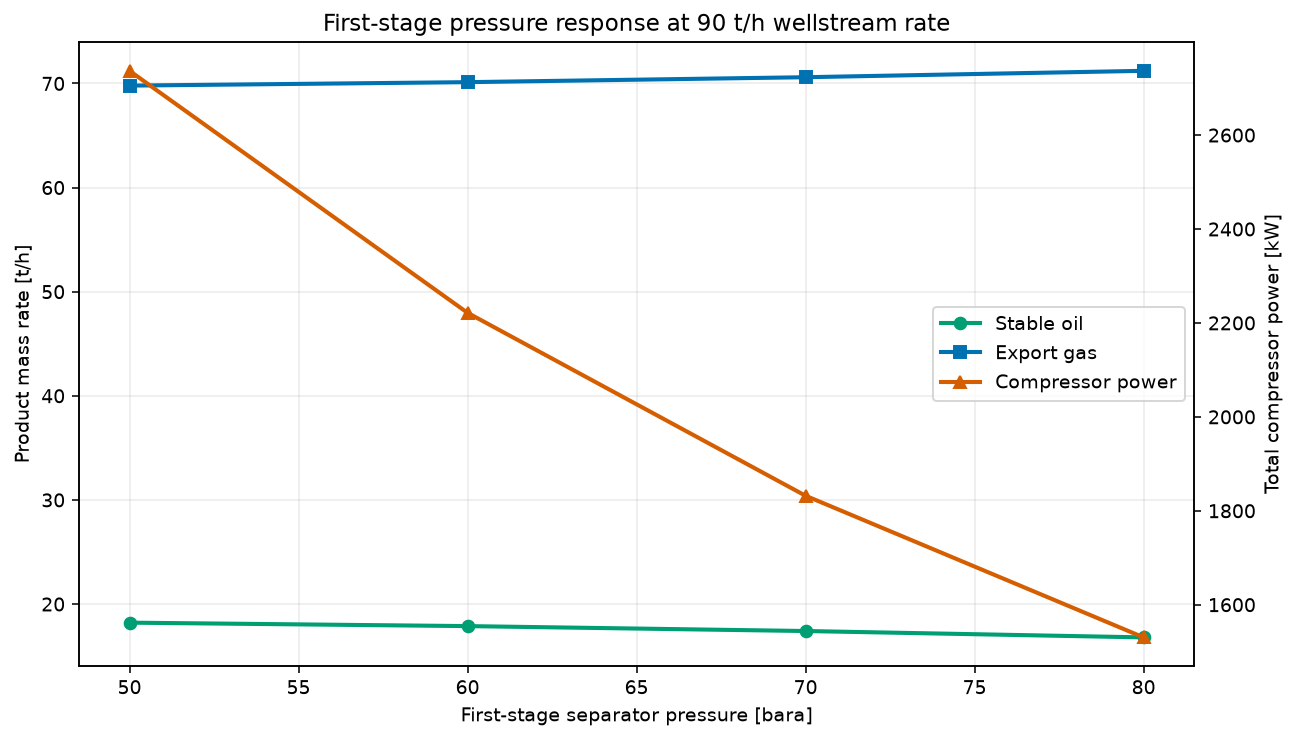

In [15]:
selected_rate_table = offshore_sensitivity.loc[
    offshore_sensitivity["Feed rate [kg/h]"] == 90_000.0
].copy()

fig, rate_axis = plt.subplots(figsize=(9.4, 5.4))
power_axis = rate_axis.twinx()

rate_axis.plot(
    selected_rate_table["HP pressure [bara]"],
    selected_rate_table["Stable oil [kg/h]"] / 1_000.0,
    color="#009E73",
    marker="o",
    linewidth=2.1,
    label="Stable oil",
)
rate_axis.plot(
    selected_rate_table["HP pressure [bara]"],
    selected_rate_table["Export gas [kg/h]"] / 1_000.0,
    color="#0072B2",
    marker="s",
    linewidth=2.1,
    label="Export gas",
)
power_axis.plot(
    selected_rate_table["HP pressure [bara]"],
    selected_rate_table["Power [kW]"],
    color="#D55E00",
    marker="^",
    linewidth=2.1,
    label="Compressor power",
)
rate_axis.set_xlabel("First-stage separator pressure [bara]")
rate_axis.set_ylabel("Product mass rate [t/h]")
power_axis.set_ylabel("Total compressor power [kW]")
rate_axis.set_title(
    "First-stage pressure response at 90 t/h wellstream rate"
)
rate_axis.grid(alpha=0.25)

lines = rate_axis.get_lines() + power_axis.get_lines()
labels = [line.get_label() for line in lines]
rate_axis.legend(lines, labels, loc="center right")
plt.tight_layout()
plt.show()


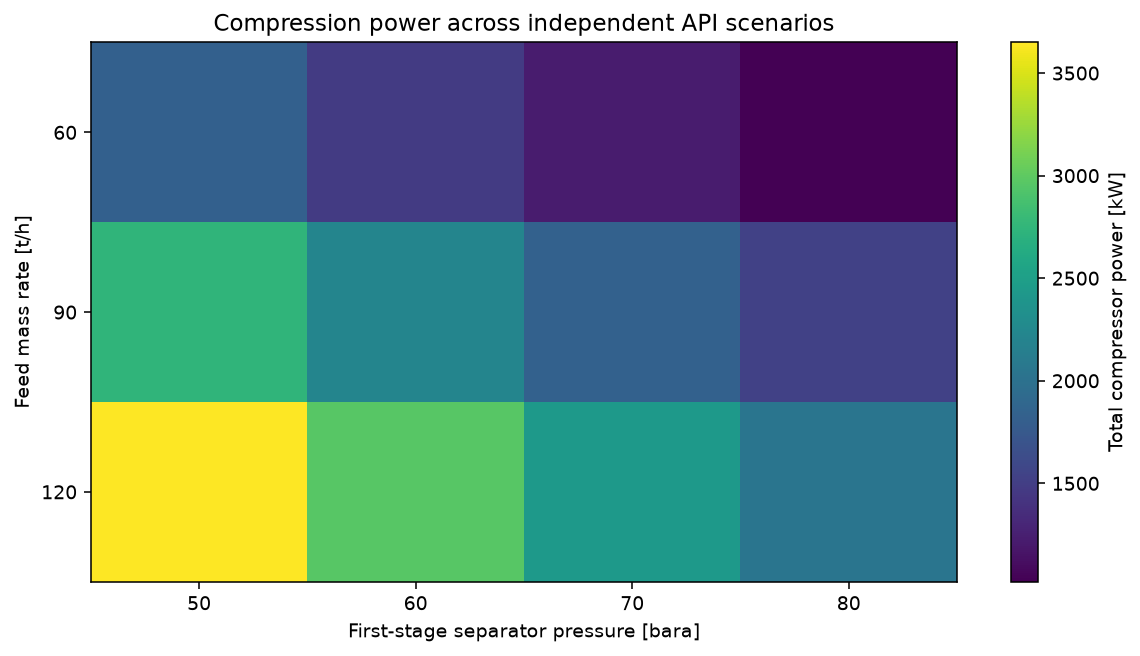

In [16]:
power_pivot = offshore_sensitivity.pivot(
    index="Feed rate [kg/h]",
    columns="HP pressure [bara]",
    values="Power [kW]",
)

fig, axis = plt.subplots(figsize=(8.6, 4.8))
image = axis.imshow(
    power_pivot.to_numpy(),
    aspect="auto",
    cmap="viridis",
)
axis.set_xticks(
    np.arange(len(power_pivot.columns)),
    labels=[f"{value:.0f}" for value in power_pivot.columns],
)
axis.set_yticks(
    np.arange(len(power_pivot.index)),
    labels=[f"{value / 1_000.0:.0f}" for value in power_pivot.index],
)
axis.set_xlabel("First-stage separator pressure [bara]")
axis.set_ylabel("Feed mass rate [t/h]")
axis.set_title("Compression power across independent API scenarios")
colorbar = fig.colorbar(image, ax=axis)
colorbar.set_label("Total compressor power [kW]")
plt.tight_layout()
plt.show()


Higher first-stage pressure reduces the total compression ratio for flash gas and therefore lowers
power in this case. It also changes the gas–liquid split: stable-oil rate decreases while export-gas
rate increases. The service returns both consequences so a client can apply project-specific
constraints.


## A reusable process API facade

The dispatcher validates the path and request, runs exactly one calculation, converts NumPy values
to plain Python values, and returns a versioned response envelope. Errors are structured and do not
invoke the solver when validation fails.


In [17]:
def make_serializable(results):
    serializable = {}

    for name, value in results.items():
        if isinstance(value, np.generic):
            serializable[name] = value.item()
        elif isinstance(value, list):
            serializable[name] = [float(item) for item in value]
        else:
            serializable[name] = value

    return serializable


def process_api(path, payload):
    try:
        if path == "/teg-dehydration":
            request = validate_request(payload, TEG_DEFAULTS, endpoint="teg")
            results = calculate_teg(request)
        elif path == "/offshore-process":
            request = validate_request(
                payload,
                OFFSHORE_DEFAULTS,
                endpoint="offshore",
            )
            results = calculate_offshore(request)
        else:
            raise ValueError(f"Unknown endpoint: {path}")

        return {
            "ok": True,
            "schema_version": "1.0",
            "neqsim_version": NEQSIM_VERSION,
            "endpoint": path,
            "results": make_serializable(results),
        }
    except ValueError as error:
        return {
            "ok": False,
            "schema_version": "1.0",
            "endpoint": path,
            "error": {
                "type": "validation_error",
                "message": str(error),
            },
        }


teg_api_response = process_api(
    "/teg-dehydration",
    {"lean_teg_rate_kg_per_h": 5_500.0},
)
offshore_api_response = process_api(
    "/offshore-process",
    {"first_stage_pressure_bara": 60.0},
)
invalid_api_response = process_api(
    "/offshore-process",
    {"third_stage_pressure_bara": 75.0},
)

print(json.dumps(teg_api_response, indent=2))
print(json.dumps(offshore_api_response, indent=2))
print(json.dumps(invalid_api_response, indent=2))


{
  "ok": true,
  "schema_version": "1.0",
  "neqsim_version": "3.16.0",
  "endpoint": "/teg-dehydration",
  "results": {
    "dry_gas_water_ppmv": 8.252039951544186,
    "wet_gas_water_ppmv": 1016.0293028225518,
    "water_removal_fraction": 0.9958836305389608,
    "water_dewpoint_C": -36.81265830993652,
    "feed_hydrate_temperature_C": 17.933746591103613,
    "reboiler_duty_kW_screening": 602.0014479309233,
    "dry_gas_rate_kg_per_h": 99757.29783305843,
    "rich_teg_rate_kg_per_h": 5742.702166942229,
    "mass_residual_kg_per_h": 4.3655745685100555e-11,
    "ntu": 6.952664087768018,
    "fs_utilization_percent": 60.11023623269106
  }
}
{
  "ok": true,
  "schema_version": "1.0",
  "neqsim_version": "3.16.0",
  "endpoint": "/offshore-process",
  "results": {
    "stable_oil_rate_kg_per_h": 19870.264392932782,
    "export_gas_rate_kg_per_h": 77913.32677273077,
    "produced_water_rate_kg_per_h": 2216.408834301825,
    "export_pressure_bara": 140.0,
    "total_compressor_power_kW": 24

The successful responses include the tested NeqSim version and only serializable results. The
invalid pressure sequence produces a validation error without creating a flowsheet.


## Final application: constrained operating-point selection

For a $90{,}000\ \mathrm{kg/h}$ wellstream, the client requires at least
$17{,}500\ \mathrm{kg/h}$ stable oil and no more than $2{,}500\ \mathrm{kW}$ total compression
power. Among feasible tested pressures, the selected point maximizes stable-oil production.


In [18]:
operating_candidates = selected_rate_table.copy()
operating_candidates["Oil constraint passed"] = (
    operating_candidates["Stable oil [kg/h]"] >= 17_500.0
)
operating_candidates["Power constraint passed"] = (
    operating_candidates["Power [kW]"] <= 2_500.0
)
operating_candidates["Feasible"] = (
    operating_candidates["Oil constraint passed"]
    & operating_candidates["Power constraint passed"]
)

feasible_candidates = operating_candidates.loc[
    operating_candidates["Feasible"]
]
selected_candidate = feasible_candidates.loc[
    feasible_candidates["Stable oil [kg/h]"].idxmax()
]

print(operating_candidates.to_string(index=False))
print(
    "Selected first-stage pressure: "
    f"{selected_candidate['HP pressure [bara]']:.1f} bara"
)
print(
    "Selected stable-oil rate: "
    f"{selected_candidate['Stable oil [kg/h]']:.3f} kg/h"
)
print(
    "Selected compressor power: "
    f"{selected_candidate['Power [kW]']:.3f} kW"
)


 Feed rate [kg/h]  HP pressure [bara]  Stable oil [kg/h]  Export gas [kg/h]  Power [kW]  Mass residual [kg/h]  Oil constraint passed  Power constraint passed  Feasible
          90000.0                50.0       18213.535900       69790.591476 2736.808851          1.933950e-08                   True                    False     False
          90000.0                60.0       17883.237954       70121.994095 2221.510743          3.114110e-08                   True                     True      True
          90000.0                70.0       17410.322824       70596.865888 1831.995611          3.646710e-08                  False                     True     False
          90000.0                80.0       16798.435905       71211.218311 1530.409671          6.602204e-08                  False                     True     False
Selected first-stage pressure: 60.0 bara
Selected stable-oil rate: 17883.238 kg/h
Selected compressor power: 2221.511 kW


This selection is a discrete screening result, not a continuous optimum. A deployment can reuse the
same endpoint over a denser grid or connect it to an optimizer, while keeping validation and
engineering constraints outside the thermodynamic solver.


## Engineering verification

The checks cover request validation, deterministic responses, component normalization, mass
closure, phase products, pressure ordering, finite results, TEG trends, compressor-power trends,
and the final constrained selection.


In [19]:
repeat_offshore_response = process_api(
    "/offshore-process",
    {"first_stage_pressure_bara": 60.0},
)
teg_water_values = teg_sensitivity["Dry gas water [ppmv]"].to_numpy()
teg_duty_values = teg_sensitivity["Reboiler duty [kW]"].to_numpy()
grid_power_values = offshore_sensitivity["Power [kW]"].to_numpy()
grid_mass_residuals = offshore_sensitivity[
    "Mass residual [kg/h]"
].to_numpy()

validation_checks = {
    "composition closes": abs(composition_sum - 1.0) < 1.0e-12,
    "TEG response succeeds": bool(teg_api_response["ok"]),
    "offshore response succeeds": bool(offshore_api_response["ok"]),
    "invalid request is rejected": not bool(invalid_api_response["ok"]),
    "TEG removes water": (
        teg_result["dry_gas_water_ppmv"]
        < teg_result["wet_gas_water_ppmv"]
    ),
    "TEG water decreases with circulation": bool(
        np.all(np.diff(teg_water_values) < 0.0)
    ),
    "TEG duty rises with circulation": bool(
        np.all(np.diff(teg_duty_values) > 0.0)
    ),
    "TEG mass closes": (
        abs(teg_result["mass_residual_kg_per_h"])
        / (
            TEG_DEFAULTS["feed_gas_rate_kg_per_h"]
            + TEG_DEFAULTS["lean_teg_rate_kg_per_h"]
        )
        < 1.0e-10
    ),
    "water dew point is finite": bool(
        np.isfinite(teg_result["water_dewpoint_C"])
    ),
    "hydrate temperature is finite": bool(
        np.isfinite(teg_result["feed_hydrate_temperature_C"])
    ),
    "offshore products are positive": all(
        offshore_result[name] > 0.0
        for name in [
            "stable_oil_rate_kg_per_h",
            "export_gas_rate_kg_per_h",
            "produced_water_rate_kg_per_h",
        ]
    ),
    "offshore base mass closes": (
        abs(offshore_result["mass_residual_kg_per_h"])
        / OFFSHORE_DEFAULTS["feed_rate_kg_per_h"]
        < 1.0e-10
    ),
    "all scenarios are finite": bool(
        np.isfinite(grid_power_values).all()
    ),
    "all scenario mass balances close": bool(
        np.max(np.abs(grid_mass_residuals)) / 120_000.0 < 1.0e-10
    ),
    "pressure path is ordered": (
        offshore_result["stage_pressures_bara"][:3]
        == [70.0, 15.0, 2.0]
    ),
    "export pressure is met": abs(
        offshore_result["export_pressure_bara"] - 140.0
    ) < 1.0e-10,
    "response is deterministic": (
        repeat_offshore_response["results"]
        == offshore_api_response["results"]
    ),
    "selected point is feasible": bool(selected_candidate["Feasible"]),
}

validation_table = pd.DataFrame(
    {
        "check": validation_checks.keys(),
        "passed": validation_checks.values(),
    }
)
print(validation_table.to_string(index=False))
assert all(validation_checks.values())
print(f"All {len(validation_checks)} engineering checks passed.")


                               check  passed
                  composition closes    True
               TEG response succeeds    True
          offshore response succeeds    True
         invalid request is rejected    True
                   TEG removes water    True
TEG water decreases with circulation    True
     TEG duty rises with circulation    True
                     TEG mass closes    True
           water dew point is finite    True
       hydrate temperature is finite    True
      offshore products are positive    True
           offshore base mass closes    True
            all scenarios are finite    True
    all scenario mass balances close    True
            pressure path is ordered    True
              export pressure is met    True
           response is deterministic    True
          selected point is feasible    True
All 18 engineering checks passed.


## Troubleshooting and practical limitations

- Reject unknown fields; silently ignoring a misspelled setpoint can be dangerous.
- Require units in field names or a separate unit field and convert only at the service boundary.
- Build a fresh process per independent request unless thread safety and state management are
  explicitly designed.
- Return convergence and feasibility separately from HTTP success.
- Use timeouts, request-size limits, authentication, rate limits, structured logs, and secret
  management in a deployed service.
- Treat `SimpleTEGAbsorber` as an equilibrium-stage screening model. Detailed TEG design requires
  mass-transfer, hydraulics, regeneration, heat integration, and emissions assessment.
- Characterize real well fluids with measured PVT data and heavy fractions before using staged
  separation results for design.
- Do not expose raw stack traces, Java objects, credentials, or proprietary compositions.


## Summary and further exercises

The notebook maps validated request dictionaries to real NeqSim thermodynamic and process objects,
runs two complete engineering calculations, returns finite JSON-compatible results, and uses
conservation and trend checks to validate the service behavior.

Further exercises:

1. wrap `process_api` with FastAPI and generate an OpenAPI schema;
2. add explicit unit conversion and schema migration tests;
3. add a rigorous TEG regeneration train and energy integration;
4. characterize a heavy oil with TBP fractions and compare product vapor pressure;
5. add compressor design limits and return utilization information; and
6. run requests in isolated workers and benchmark latency and memory use.


## References

- [NeqSim documentation](https://equinor.github.io/neqsimhome/)
- [NeqSim source repository](https://github.com/equinor/neqsim)
- [NeqSim Python package](https://pypi.org/project/neqsim/)
- [FastAPI documentation](https://fastapi.tiangolo.com/)
- [OpenAPI Specification](https://spec.openapis.org/oas/latest.html)
- [Google Colab notebook guide](https://colab.research.google.com/notebooks/intro.ipynb)
